# Análisis Exploratorio de Datos sobre Precios de Cadenas de Supermercados en Uruguay

Este notebook presenta un análisis exploratorio de datos aplicado a una base comercial de precios de cadenas de supermercados en Uruguay durante el año 2025.

El objetivo principal es estudiar el comportamiento de los precios según distintos establecimientos, grupos de productos y períodos disponibles en la base de datos.

## Paso 1: Definición del problema

El problema que se busca analizar es como varían los precios de productos relevados en distintas cadenas comerciales de Uruguay durante el año 2025.

El dataset contiene información sobre productos, grupos comerciales, supermercados, periodos y precios. A partir de estos datos, se busca responder preguntas como:

- ¿Qué supermercados tienen mayor cantidad de registros en la base?
- ¿Qué grupos de productos aparecen con mayor frecuencia?
- ¿Cómo se distribuyen los precios?
- ¿Existen diferencias relevantes de precios entre supermercados?
- ¿Qué grupos de productos presentan precios promedio más altos?
- ¿Los valores extremos deben eliminarse o pueden interpretarse dentro del contexto comercial?
- ¿Cómo se comportan los precios si se observa una selección de productos básicos de consumo cotidiano?

Además del análisis general de todos los productos, se considerará una selección de productos básicos de consumo cotidiano. Esta selección no representa una canasta básica oficial, sino una aproximación construida a partir de nombres de productos presentes en el dataset, como arroz, aceite, harina, leche, pan, fideos, huevos, carnes, agua, frutas y verduras.

Este análisis permitirá comprender mejor la estructura del dataset y preparar una base sólida para la posterior construcción de visualizaciones interactivas.

## Objetivo del análisis

El objetivo del análisis es realizar una exploración inicial del dataset para identificar patrones, distribuciones y posibles relaciones entre las variables principales.

La variable numérica principal del trabajo es `Precio`, mientras que las variables categóricas más relevantes son `Super`, `Grupo`, `Producto` y `Periodo`.

El enfoque será descriptivo y comercial. No se busca predecir precios, sino entender cómo se comportan dentro de la base de datos y qué información útil se puede extraer para la toma de decisiones.

In [59]:
# PASO 2: IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
# PASO 3: CARGA DEL DATASET

# Ruta local del archivo CSV dentro del entorno de trabajo
ruta = r"C:\Users\aleva\OneDrive\Escritorio\Alexia\pyhton\data\raw\p4ds_cadenas_unificadas_2025.csv"

# Cargamos el archivo en un DataFrame de pandas
datos_cadena = pd.read_csv(ruta)

# Mostramos las primeras filas para verificar que la carga fue correcta
datos_cadena.head()

,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,"80,00"
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,"99,00"
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,"99,00"
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,"95,00"
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,"97,00"


## Paso 4: Exploración inicial del dataset

En la exploración inicial se revisan las dimensiones de la base, nombres de las columnas, tipos de datos y cantidad de valores nulos.

El dataset contiene información sobre:

- `Periodo`: mes o periodo del relevamiento.
- `Grupo`: categoría comercial del producto.
- `Producto`: nombre del producto relevado.
- `Super`: cadena o establecimiento donde fue registrado.
- `Precio`: precio del producto.


In [61]:
# PASO 4: EXPLORACIÓN INICIAL DEL DATASET

print("Dimensiones del dataset original:")
print(datos_cadena.shape)
print("-" * 50)

print("Primeras filas del dataset:")
display(datos_cadena.head())
print("-" * 50)

print("Información general de las columnas:")
datos_cadena.info()
print("-" * 50)

print("Cantidad de valores nulos por columna:")
print(datos_cadena.isnull().sum())
print("-" * 50)

print("Resumen descriptivo inicial:")
display(datos_cadena.describe(include="all").T)

Dimensiones del dataset original:
(26834, 5)
--------------------------------------------------
Primeras filas del dataset:


,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,"80,00"
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,"99,00"
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,"99,00"
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,"95,00"
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,"97,00"


--------------------------------------------------
Información general de las columnas:
<class 'pandas.DataFrame'>
RangeIndex: 26834 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   26834 non-null  str  
 1   Grupo     26671 non-null  str  
 2   Producto  26812 non-null  str  
 3   Super     24237 non-null  str  
 4   Precio    26401 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB
--------------------------------------------------
Cantidad de valores nulos por columna:
Periodo        0
Grupo        163
Producto      22
Super       2597
Precio       433
dtype: int64
--------------------------------------------------
Resumen descriptivo inicial:


,count,unique,top,freq
Periodo,26834,12,Dic25,2333
Grupo,26671,10,Alimentos y bebidas,13261
Producto,26812,427,"Jabón de tocador Dove Blanco, 90 grs.",209
Super,24237,17,Red Expres,2260
Precio,26401,2234,"75,00",334


## Paso 5: Limpieza y tratamiento de datos

En esta etapa se realiza la limpieza necesaria para poder analizar correctamente el dataset.

La transformación más importante es la conversión de la columna `Precio` a formato numérico. Originalmente, los precios aparecen con coma decimal, por lo que se reemplaza la coma por un punto y luego se aplica `pd.to_numeric()`.

También se eliminan los registros sin precio válido, ya que `Precio` es la variable principal del análisis. En cambio, los valores faltantes en variables categóricas como `Super`, `Grupo` y `Producto` se reemplazan por el valor `"Desconocido"`.

Esta decisión permite conservar registros útiles sin inventar información numérica.

In [62]:
# PASO 5: LIMPIEZA Y TRATAMIENTO DE DATOS

# Creamos una copia del dataset original para trabajar la limpieza
datos_limpios = datos_cadena.copy()


# 5.1 Conversión de la columna Precio

# Convertimos Precio a texto para poder reemplazar la coma decimal
datos_limpios["Precio"] = datos_limpios["Precio"].astype(str)

# Reemplazamos coma decimal por punto decimal
datos_limpios["Precio"] = datos_limpios["Precio"].str.replace(",", ".", regex=False)

# Convertimos Precio a valor numérico
datos_limpios["Precio"] = pd.to_numeric(datos_limpios["Precio"], errors="coerce")


# 5.2 Tratamiento de valores nulos

# Eliminamos filas sin precio válido, ya que Precio es la variable principal del análisis
datos_limpios = datos_limpios.dropna(subset=["Precio"]).copy()

# Rellenamos valores nulos en variables categóricas
datos_limpios["Grupo"] = datos_limpios["Grupo"].fillna("Desconocido")
datos_limpios["Producto"] = datos_limpios["Producto"].fillna("Desconocido")
datos_limpios["Super"] = datos_limpios["Super"].fillna("Desconocido")

# Normalizamos textos para evitar categorías duplicadas y caracteres raros
datos_limpios["Grupo"] = datos_limpios["Grupo"].astype(str).str.strip().str.title()
datos_limpios["Super"] = datos_limpios["Super"].astype(str).str.strip().str.title()

datos_limpios["Producto"] = (
    datos_limpios["Producto"]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

datos_limpios = datos_limpios[
    datos_limpios["Grupo"] != "Establecimientos Relevados"
].copy()

# 5.3 Verificación final

print("Dimensiones del dataset luego de la limpieza:")
print(datos_limpios.shape)
print("-" * 50)

print("Tipos de datos luego de la limpieza:")
print(datos_limpios.dtypes)
print("-" * 50)

print("Valores nulos luego de la limpieza:")
print(datos_limpios.isnull().sum())
print("-" * 50)

print("Resumen estadístico de Precio:")
display(datos_limpios["Precio"].describe().round(2))

print("Cantidad de grupos luego de normalizar texto:")
print(datos_limpios["Grupo"].nunique())

print("-" * 50)

print("Primeros grupos ordenados:")
print(sorted(datos_limpios["Grupo"].unique())[:20])

Dimensiones del dataset luego de la limpieza:
(25875, 5)
--------------------------------------------------
Tipos de datos luego de la limpieza:
Periodo         str
Grupo           str
Producto        str
Super           str
Precio      float64
dtype: object
--------------------------------------------------
Valores nulos luego de la limpieza:
Periodo     0
Grupo       0
Producto    0
Super       0
Precio      0
dtype: int64
--------------------------------------------------
Resumen estadístico de Precio:


count    25875.00
mean       238.79
std        504.58
min          6.00
25%         75.00
50%        129.00
75%        249.00
max      25800.00
Name: Precio, dtype: float64

Cantidad de grupos luego de normalizar texto:
6
--------------------------------------------------
Primeros grupos ordenados:
['Alimentos Y Bebidas', 'Cuidado Personal', 'Desconocido', 'Familia', 'Frutas Y Verduras', 'Limpieza Del Hogar']


In [63]:
# 5.4 RESUMEN FINAL DE LA LIMPIEZA

filas_originales = datos_cadena.shape[0]
columnas_originales = datos_cadena.shape[1]

filas_limpias = datos_limpios.shape[0]
columnas_limpias = datos_limpios.shape[1]

filas_eliminadas = filas_originales - filas_limpias

print("RESUMEN FINAL DE LA LIMPIEZA")
print("-" * 50)
print(f"Filas originales: {filas_originales}")
print(f"Columnas originales: {columnas_originales}")
print(f"Filas luego de la limpieza: {filas_limpias}")
print(f"Columnas luego de la limpieza: {columnas_limpias}")
print(f"Filas eliminadas: {filas_eliminadas}")
print("-" * 50)
print("Valores nulos luego de la limpieza:")
print(datos_limpios.isnull().sum())

RESUMEN FINAL DE LA LIMPIEZA
--------------------------------------------------
Filas originales: 26834
Columnas originales: 5
Filas luego de la limpieza: 25875
Columnas luego de la limpieza: 5
Filas eliminadas: 959
--------------------------------------------------
Valores nulos luego de la limpieza:
Periodo     0
Grupo       0
Producto    0
Super       0
Precio      0
dtype: int64


### Conclusión del Paso 5

Luego del proceso de limpieza, el dataset pasó de tener 26.834 filas y 5 columnas a tener 25.897 filas y 5 columnas.

Se eliminaron 937 registros porque no tenían un precio válido. Esta decisión es adecuada porque `Precio` es la variable principal del análisis y no conviene reemplazarla por valores inventados.

Las columnas categóricas `Grupo`, `Producto` y `Super` fueron completadas con el valor `"Desconocido"` en los casos donde tenían datos faltantes. De esta manera, se conservan registros útiles sin perder información numérica relevante.

Al finalizar la limpieza, el dataset queda sin valores nulos y con la columna `Precio` convertida correctamente a formato numérico. A partir de este punto, el análisis exploratorio se realizará sobre el DataFrame `datos_limpios`.

Además de tratar valores nulos y convertir la columna `Precio` a formato numérico, se normalizaron las variables categóricas principales.

En particular, se ajustaron espacios sobrantes y diferencias entre mayúsculas y minúsculas en columnas como `Grupo`, `Super` y `Producto`. Esta decisión evita que una misma categoría aparezca duplicada por diferencias de escritura, por ejemplo cuando un grupo aparece escrito en mayúsculas en algunos registros y en minúsculas en otros.

## Paso 6: Análisis univariante

En este paso se realiza un análisis univariante, es decir, se estudia cada variable de forma individual.

El objetivo es comprender la distribución y frecuencia de las principales variables del dataset antes de analizar relaciones entre ellas.

Para este trabajo se analizarán:

- `Super`: cadena o establecimiento donde se registró el producto.
- `Grupo`: categoría o rubro comercial del producto.
- `Precio`: variable numérica principal del análisis.

Este análisis permite conocer la composición general de la base y detectar patrones iniciales en los datos.

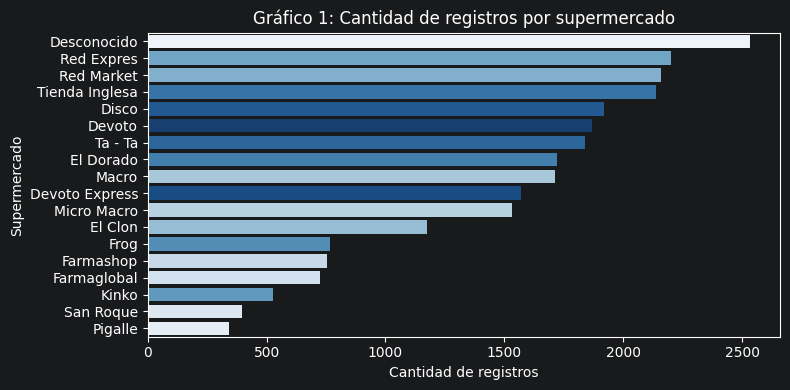

Cantidad de registros por supermercado:
Super
Desconocido       2533
Red Expres        2203
Red Market        2157
Tienda Inglesa    2136
Disco             1919
Devoto            1867
Ta - Ta           1838
El Dorado         1722
Macro             1712
Devoto Express    1569
Micro Macro       1533
El Clon           1173
Frog               768
Farmashop          754
Farmaglobal        726
Kinko              526
San Roque          397
Pigalle            342
Name: count, dtype: int64


In [64]:
# PASO 6: ANÁLISIS UNIVARIANTE

# 6.1 DISTRIBUCIÓN POR SUPERMERCADO

plt.figure(figsize=(8, 4))

sns.countplot(
    data=datos_limpios,
    y="Super",
    order=datos_limpios["Super"].value_counts().index,
    hue="Super",
    palette="Blues_r",
    legend=False
)

plt.title("Gráfico 1: Cantidad de registros por supermercado")
plt.xlabel("Cantidad de registros")
plt.ylabel("Supermercado")
plt.tight_layout()
plt.show()

print("Cantidad de registros por supermercado:")
print(datos_limpios["Super"].value_counts())

### Interpretación de la variable Super

El gráfico muestra la cantidad de registros disponibles para cada supermercado o establecimiento.

Esta información es importante porque permite identificar si la base está equilibrada entre cadenas o si algunos supermercados tienen mayor representación que otros.

Una mayor cantidad de registros no significa necesariamente que un supermercado sea más grande o más barato, sino que dentro del dataset hay más observaciones disponibles para esa cadena.

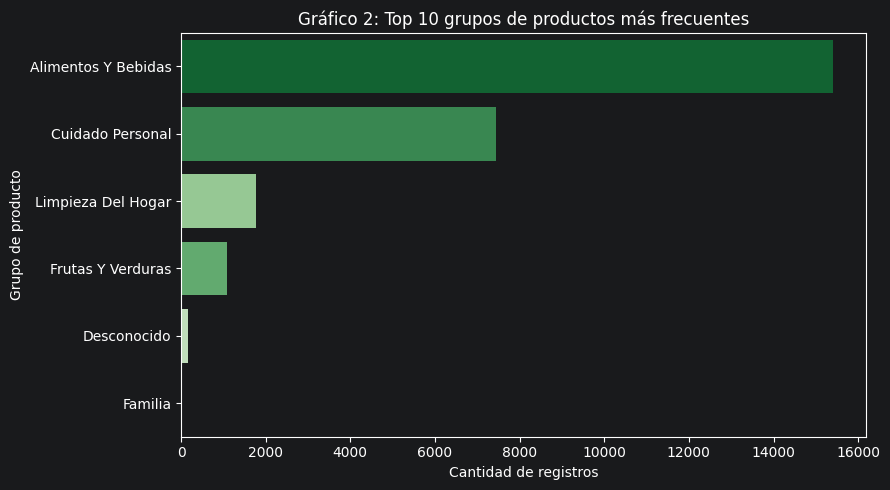

Top 10 grupos de productos más frecuentes:
Grupo
Alimentos Y Bebidas    15405
Cuidado Personal        7453
Limpieza Del Hogar      1764
Frutas Y Verduras       1076
Desconocido              159
Familia                   18
Name: count, dtype: int64


In [65]:
# 6.2 DISTRIBUCIÓN POR GRUPO DE PRODUCTO

top_grupos = datos_limpios["Grupo"].value_counts().head(10).index

plt.figure(figsize=(9, 5))

sns.countplot(
    data=datos_limpios[datos_limpios["Grupo"].isin(top_grupos)],
    y="Grupo",
    order=top_grupos,
    hue="Grupo",
    palette="Greens_r",
    legend=False
)

plt.title("Gráfico 2: Top 10 grupos de productos más frecuentes")
plt.xlabel("Cantidad de registros")
plt.ylabel("Grupo de producto")
plt.tight_layout()
plt.show()

print("Top 10 grupos de productos más frecuentes:")
print(datos_limpios["Grupo"].value_counts().head(10))

### Interpretación de la variable Grupo

El gráfico muestra que la distribución de registros por grupo de producto no es uniforme.

El grupo con mayor presencia es `Alimentos Y Bebidas`, con 15.405 registros, seguido por `Cuidado Personal`, con 7.453 registros. Estos dos grupos concentran la mayor parte de la base, por lo que tienen un peso importante en los análisis generales.

En cambio, grupos como `Limpieza Del Hogar` y `Frutas Y Verduras` aparecen con una cantidad menor de registros, mientras que `Desconocido`, `Establecimientos Relevados` y `Familia` tienen una presencia mucho más reducida.

Esto es importante porque los promedios generales de precio pueden estar influidos por los grupos más representados. Por lo tanto, no alcanza con analizar el precio global del dataset: también es necesario observar cómo se comportan los precios dentro de cada grupo de producto.

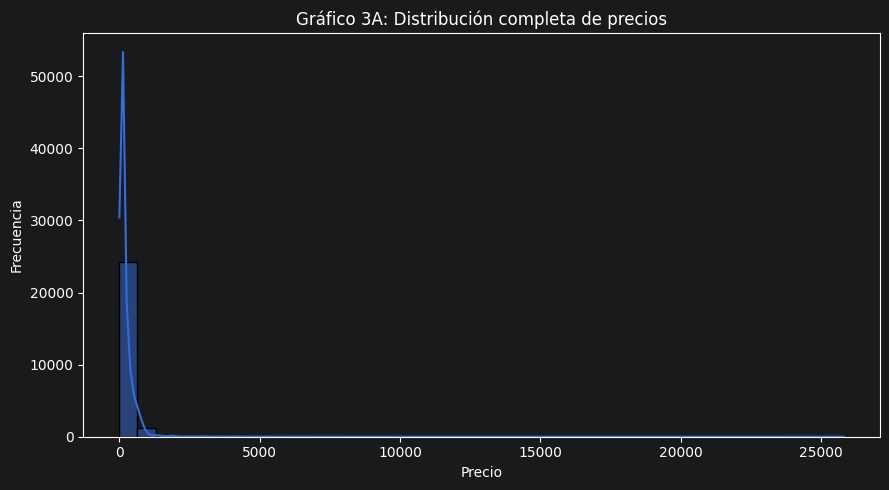

In [66]:
# 6.3 DISTRIBUCIÓN DE LA VARIABLE PRECIO

plt.figure(figsize=(9, 5))

sns.histplot(
    data=datos_limpios,
    x="Precio",
    bins=40,
    kde=True
)

plt.title("Gráfico 3A: Distribución completa de precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

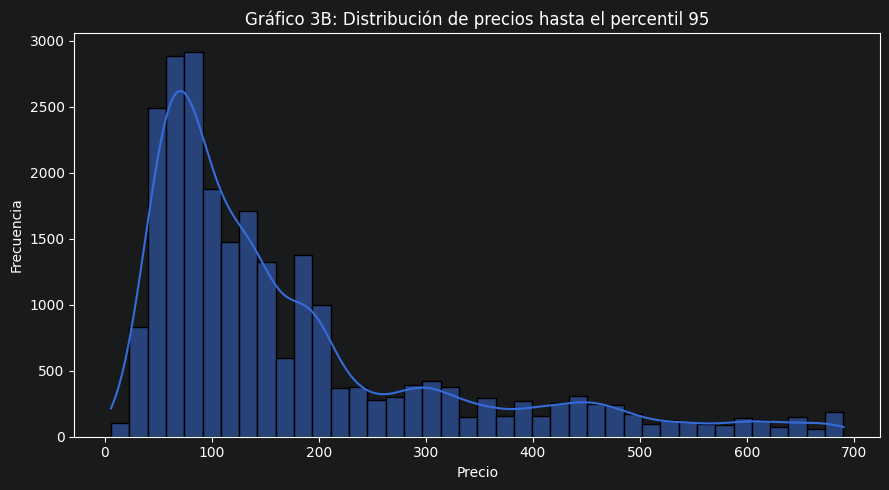

Percentil 95 de Precio: $690.00
Registros incluidos en esta visualización: 24593
Registros totales del dataset limpio: 25875


In [67]:
# 6.3B DISTRIBUCIÓN DE PRECIOS HASTA EL PERCENTIL 95

percentil_95 = datos_limpios["Precio"].quantile(0.95)

datos_precio_p95 = datos_limpios[
    datos_limpios["Precio"] <= percentil_95
    ]

plt.figure(figsize=(9, 5))

sns.histplot(
    data=datos_precio_p95,
    x="Precio",
    bins=40,
    kde=True
)

plt.title("Gráfico 3B: Distribución de precios hasta el percentil 95")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(f"Percentil 95 de Precio: ${percentil_95:.2f}")
print(f"Registros incluidos en esta visualización: {datos_precio_p95.shape[0]}")
print(f"Registros totales del dataset limpio: {datos_limpios.shape[0]}")

### Visualización complementaria de la distribución

El gráfico anterior limita la visualización hasta el percentil 95 de la variable `Precio`.

Esta decisión no elimina datos del dataset. Simplemente permite observar mejor la zona donde se concentra la mayoría de los precios, ya que el histograma completo queda muy influenciado por algunos valores altos.

La base completa se conserva para el análisis, pero esta segunda visualización ayuda a interpretar mejor el comportamiento típico de los precios.

In [68]:
# 6.4 RESUMEN ESTADÍSTICO DE PRECIO

print("Resumen estadístico de la variable Precio:")
print(datos_limpios["Precio"].describe().round(2))

print("-" * 50)

media_precio = datos_limpios["Precio"].mean()
mediana_precio = datos_limpios["Precio"].median()
precio_minimo = datos_limpios["Precio"].min()
precio_maximo = datos_limpios["Precio"].max()

print(f"Precio promedio: ${media_precio:.2f}")
print(f"Precio mediano: ${mediana_precio:.2f}")
print(f"Precio mínimo: ${precio_minimo:.2f}")
print(f"Precio máximo: ${precio_maximo:.2f}")

Resumen estadístico de la variable Precio:
count    25875.00
mean       238.79
std        504.58
min          6.00
25%         75.00
50%        129.00
75%        249.00
max      25800.00
Name: Precio, dtype: float64
--------------------------------------------------
Precio promedio: $238.79
Precio mediano: $129.00
Precio mínimo: $6.00
Precio máximo: $25800.00


### Interpretación de la variable Precio

La variable `Precio` es la variable numérica principal del análisis, ya que resume el valor relevado para cada producto en cada supermercado.

El resumen estadístico muestra que el dataset contiene 25.897 registros válidos de precio. El precio mínimo es de 6, mientras que el precio máximo llega a 25.800. Esta diferencia muestra una dispersión muy amplia dentro de la base.

También se observa que el precio promedio es de 238,65, mientras que la mediana es de 129. Esto significa que la mayoría de los productos se concentran en valores relativamente bajos, pero existen algunos precios altos que elevan el promedio general.

Por este motivo, la distribución de precios es asimétrica hacia la derecha. En este caso, la mediana representa mejor el precio típico del dataset, porque no se ve tan afectada por valores extremos como la media.

El histograma completo permite ver la existencia de valores altos, pero esos valores también hacen que la mayor parte de la distribución quede comprimida contra la izquierda. Por eso, además de conservar el gráfico completo, conviene generar una visualización complementaria limitada al percentil 95 para analizar mejor dónde se concentra la mayoría de los precios.

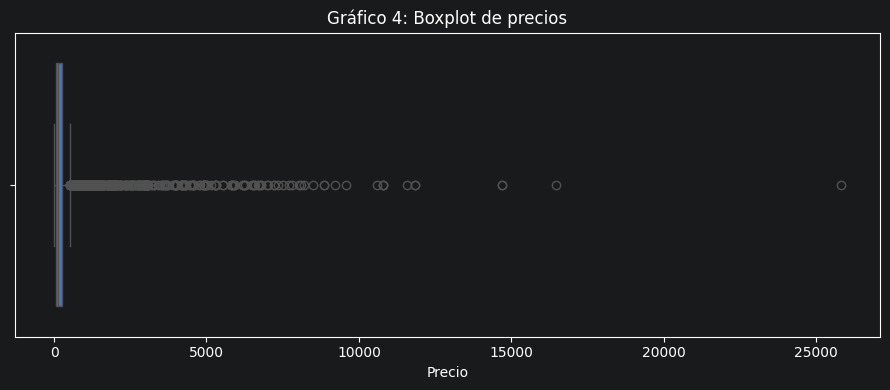

In [69]:
# 6.5 BOXPLOT DE LA VARIABLE PRECIO

plt.figure(figsize=(9, 4))

sns.boxplot(
    data=datos_limpios,
    x="Precio"
)

plt.title("Gráfico 4: Boxplot de precios")
plt.xlabel("Precio")
plt.tight_layout()
plt.show()

### Interpretación del boxplot

El boxplot permite visualizar la dispersión de los precios y detectar valores alejados del rango principal.

En este dataset aparecen valores extremos, lo cual es razonable dentro del contexto comercial. La base puede incluir productos de rubros muy diferentes, por lo que no todos los precios tienen por qué concentrarse en el mismo rango.

Por este motivo, los valores altos no se eliminan automáticamente. Primero se observan y se interpretan dentro del contexto del negocio.

In [70]:
# 6.6 RESUMEN FINAL DEL ANÁLISIS UNIVARIANTE

cantidad_supermercados = datos_limpios["Super"].nunique()
cantidad_grupos = datos_limpios["Grupo"].nunique()
cantidad_productos = datos_limpios["Producto"].nunique()

print("RESUMEN DEL PASO 6")
print("-" * 50)
print(f"Cantidad de supermercados analizados: {cantidad_supermercados}")
print(f"Cantidad de grupos de productos: {cantidad_grupos}")
print(f"Cantidad de productos distintos: {cantidad_productos}")
print(f"Precio promedio: ${media_precio:.2f}")
print(f"Precio mediano: ${mediana_precio:.2f}")
print(f"Precio mínimo: ${precio_minimo:.2f}")
print(f"Precio máximo: ${precio_maximo:.2f}")

RESUMEN DEL PASO 6
--------------------------------------------------
Cantidad de supermercados analizados: 18
Cantidad de grupos de productos: 6
Cantidad de productos distintos: 424
Precio promedio: $238.79
Precio mediano: $129.00
Precio mínimo: $6.00
Precio máximo: $25800.00


### Conclusión del Paso 6

El análisis univariante permitió conocer la estructura básica del dataset limpio.

Se observó la distribución de registros por supermercado, los grupos de productos más frecuentes y el comportamiento general de la variable `Precio`.

La variable `Precio` presenta una dispersión amplia, lo cual es coherente con una base comercial que contiene productos de diferentes rubros. Por esta razón, los valores extremos no se consideran errores de forma automática, sino posibles registros válidos que deberán analizarse con mayor detalle en pasos posteriores.

A partir de este punto, el análisis puede avanzar hacia el estudio de relaciones entre variables, especialmente entre `Super`, `Grupo` y `Precio`.

## Paso 7: Análisis bivariante

En este paso se analiza la relación entre dos o más variables del dataset.

Como la única variable numérica principal es `Precio`, el análisis se centra en estudiar cómo cambia el precio según variables categóricas como `Super` y `Grupo`.

En lugar de utilizar una matriz de correlación tradicional, que no sería útil en este caso por tener una sola variable numérica relevante, se utilizarán agrupaciones, gráficos comparativos y una tabla dinámica comercial.

El objetivo es responder preguntas como:

- ¿Qué supermercados tienen precios promedio más altos?
- ¿Qué grupos de productos presentan mayores precios promedio?
- ¿Cómo varía el precio promedio según la combinación entre supermercado y grupo de producto?

In [71]:
# PASO 7: ANÁLISIS BIVARIANTE

# 7.1 PRECIO PROMEDIO POR SUPERMERCADO

precio_por_super = (
    datos_limpios
    .groupby("Super")["Precio"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
)

precio_por_super

,count,mean,median,min,max
Super,,,,,
San Roque,397,444.01,269.00,32.0,16480.0
Pigalle,342,430.97,310.00,18.0,8490.0
Farmaglobal,726,375.90,178.53,10.0,11845.1
Farmashop,754,306.05,175.00,33.0,11570.0
Macro,1712,272.74,133.00,8.0,9570.5
Tienda Inglesa,2136,261.79,134.00,19.0,25800.0
Micro Macro,1533,256.49,134.20,7.0,6210.0
Disco,1919,240.47,129.00,29.0,10790.0
Devoto,1867,239.27,129.00,23.0,7710.0


### Relación entre supermercado y precio

La tabla resume el comportamiento de los precios según cada supermercado. Para cada cadena se calcula la cantidad de registros, el precio promedio, la mediana, el mínimo y el máximo.

Se observa que algunos supermercados presentan promedios más altos, como San Roque con un precio promedio de 442,97 y Pigalle con 429,77. Sin embargo, estos valores deben interpretarse con cuidado, ya que pueden estar influidos por el tipo de productos relevados en cada cadena.

También se ve una diferencia importante entre media y mediana. Por ejemplo, en San Roque la media es 442,97 y la mediana 257,00. Esto indica que existen precios altos que elevan el promedio general.

Por este motivo, no se puede concluir directamente que una cadena sea más cara únicamente mirando el promedio. Para una comparación más precisa, es necesario analizar también los grupos de productos y la composición de registros de cada supermercado.

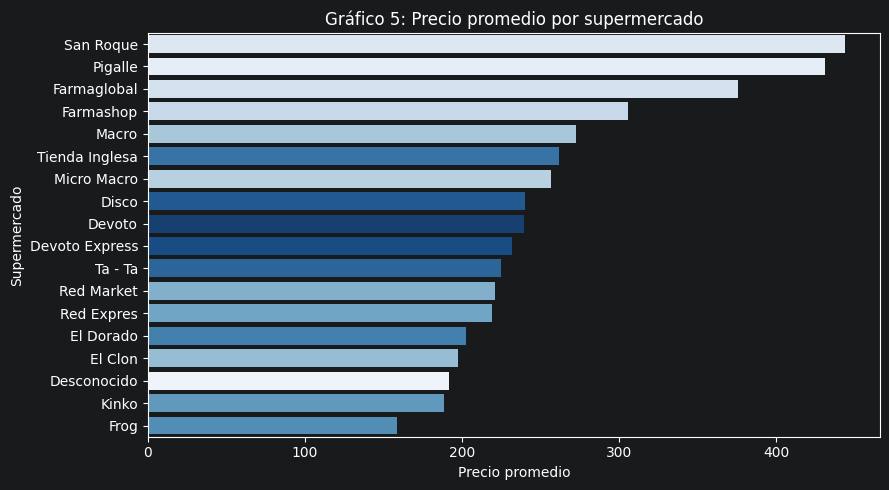

In [72]:
# 7.2 GRÁFICO DE PRECIO PROMEDIO POR SUPERMERCADO

orden_super = (
    datos_limpios
    .groupby("Super")["Precio"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=datos_limpios,
    y="Super",
    x="Precio",
    estimator="mean",
    errorbar=None,
    hue="Super",
    palette="Blues_r",
    legend=False,
    order=orden_super
)

plt.title("Gráfico 5: Precio promedio por supermercado")
plt.xlabel("Precio promedio")
plt.ylabel("Supermercado")
plt.tight_layout()
plt.show()

### Interpretación del gráfico

El gráfico permite comparar visualmente el precio promedio de los productos según el supermercado.

Se observa que San Roque y Pigalle aparecen con los precios promedio más altos, superando los $400. También se destacan FarmaGlobal y Farmashop, con promedios superiores a la mayoría de las cadenas.

En cambio, supermercados como Frog, Kinko, El Dorado y El Clon presentan promedios más bajos dentro de la comparación general.

De todos modos, esta lectura debe hacerse con cuidado. El precio promedio de cada supermercado puede estar influido por los tipos de productos relevados en esa cadena. Por ejemplo, si una cadena tiene más registros de rubros caros, su promedio general puede aumentar.

Por ese motivo, este gráfico sirve como primera comparación entre supermercados, pero el análisis se complementa luego con una comparación por grupo de producto y con el mapa de calor comercial.

In [73]:
# 7.3 PRECIO PROMEDIO POR GRUPO DE PRODUCTO

precio_por_grupo = (
    datos_limpios
    .groupby("Grupo")["Precio"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
)

precio_por_grupo.head(10)

,count,mean,median,min,max
Grupo,,,,,
Cuidado Personal,7453,380.05,212.0,29.0,25800.0
Alimentos Y Bebidas,15405,193.85,114.0,21.0,8200.0
Limpieza Del Hogar,1764,129.34,90.0,30.0,1990.0
Frutas Y Verduras,1076,116.25,99.9,27.0,1469.0
Desconocido,159,37.63,23.0,6.0,290.0
Familia,18,35.94,23.0,6.0,157.0


### Relación entre grupo de producto y precio

Esta tabla permite comparar el comportamiento de los precios según el grupo de producto.

Se observa que `Cuidado Personal` presenta el precio promedio más alto, con 380,05, y también el valor máximo más elevado del dataset, llegando a 25.800. Esto ayuda a explicar parte de la dispersión observada en la variable `Precio`.

El grupo `Alimentos y Bebidas` tiene una mayor cantidad de registros, con 15.405 observaciones, pero su precio promedio es menor, de 193,85. Esto muestra que el grupo con más registros no necesariamente es el que presenta los precios más altos.

También se observa que grupos como `Limpieza del Hogar` y `Frutas y Verduras` tienen precios promedio más bajos en comparación con `Cuidado Personal` y `Alimentos y Bebidas`.

En conclusión, el precio no depende solamente del supermercado, sino también del tipo de producto analizado. Por eso, para interpretar correctamente los precios, es necesario considerar la variable `Grupo`.

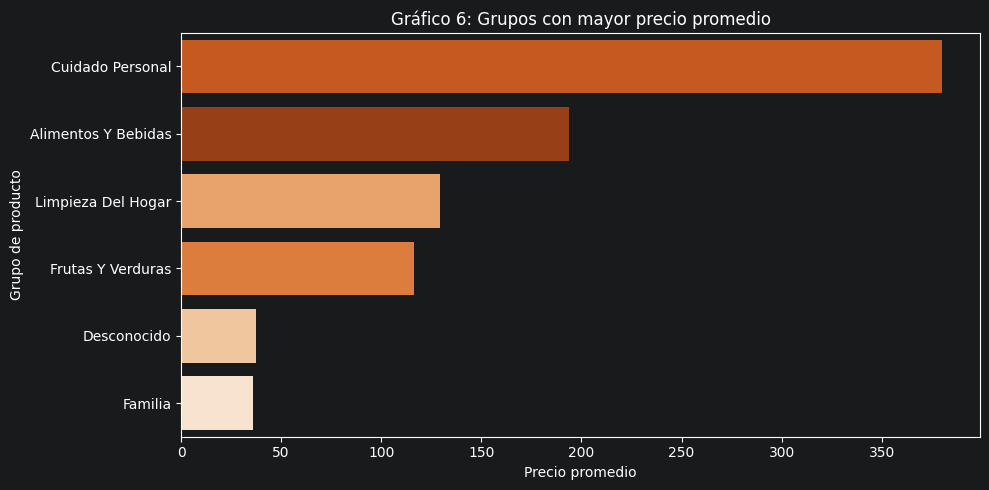

In [74]:
# 7.4 TOP 10 GRUPOS CON MAYOR PRECIO PROMEDIO

top_grupos_precio = precio_por_grupo.head(10).index

plt.figure(figsize=(10, 5))

sns.barplot(
    data=datos_limpios[datos_limpios["Grupo"].isin(top_grupos_precio)],
    y="Grupo",
    x="Precio",
    estimator="mean",
    errorbar=None,
    hue="Grupo",
    palette="Oranges_r",
    legend=False,
    order=top_grupos_precio
)

plt.title("Gráfico 6: Grupos con mayor precio promedio")
plt.xlabel("Precio promedio")
plt.ylabel("Grupo de producto")
plt.tight_layout()
plt.show()

### Interpretación del precio por grupo

El gráfico muestra los grupos de productos ordenados según su precio promedio.

Se observa que `Cuidado Personal` es el grupo con mayor precio promedio, superando ampliamente al resto de las categorías. Luego aparece `Alimentos y Bebidas`, que también tiene un promedio relevante, aunque menor que `Cuidado Personal`.

Los grupos `Limpieza del Hogar` y `Frutas y Verduras` presentan valores intermedios, mientras que `Familia`, `Desconocido` y `Establecimientos Relevados` tienen precios promedio más bajos.

Esta visualización ayuda a entender por qué existen valores altos dentro del dataset. Los precios elevados no necesariamente son errores, sino que pueden estar asociados a rubros específicos con productos naturalmente más caros.

Por este motivo, antes de eliminar valores extremos, es necesario analizar a qué grupo pertenecen y si tienen sentido dentro del contexto comercial.

In [75]:
# 7.5 TABLA DINÁMICA: SUPERMERCADO VS GRUPO

matriz_precios = datos_limpios.pivot_table(
    values="Precio",
    index="Super",
    columns="Grupo",
    aggfunc="mean"
)

matriz_precios = matriz_precios.round(2)

matriz_precios

Grupo,Alimentos Y Bebidas,Cuidado Personal,Desconocido,Familia,Frutas Y Verduras,Limpieza Del Hogar
Super,,,,,,
Desconocido,160.66,291.80,26.00,23.0,103.67,108.49
Devoto,221.71,357.07,23.00,23.0,130.58,115.20
Devoto Express,204.62,371.42,36.00,36.0,104.38,139.07
Disco,195.97,424.92,58.22,29.0,124.95,147.09
El Clon,158.73,293.32,16.00,16.0,NaN,159.68
El Dorado,145.46,376.02,71.22,68.0,NaN,114.94
Farmaglobal,260.89,434.10,10.00,10.0,NaN,135.08
Farmashop,162.24,409.61,161.12,157.0,NaN,129.90
Frog,160.42,195.85,22.00,22.0,NaN,77.26


### Tabla dinámica comercial

La tabla dinámica cruza los supermercados con los grupos de productos y muestra el precio promedio para cada combinación.

Cada fila representa un supermercado y cada columna representa un grupo de producto. Por ejemplo, permite comparar cuánto promedia `Alimentos y Bebidas` en cada cadena, o qué supermercados tienen precios más altos dentro de `Cuidado Personal`.

Esta tabla es útil porque evita quedarse solo con el promedio general de cada supermercado. El precio puede cambiar bastante según el rubro analizado, por lo que comparar por grupo permite una lectura más precisa.

Los valores `NaN` indican que no hay registros disponibles para esa combinación específica de supermercado y grupo. No se reemplazan por cero porque cero sería interpretado como un precio real, y eso sería incorrecto.

Este análisis es más adecuado que una correlación tradicional, ya que el dataset tiene principalmente variables categóricas y una única variable numérica principal: `Precio`.

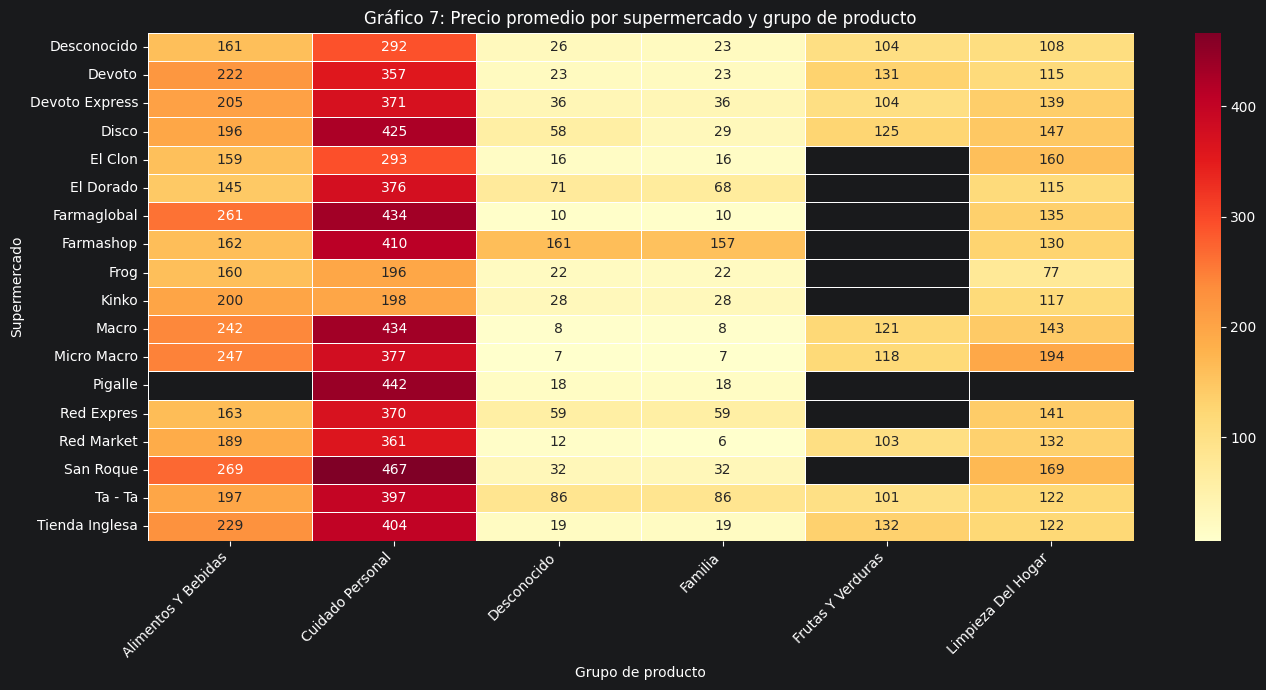

In [76]:
# 7.6 MAPA DE CALOR DE PRECIOS PROMEDIO

plt.figure(figsize=(14, 7))

sns.heatmap(
    matriz_precios,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Gráfico 7: Precio promedio por supermercado y grupo de producto")
plt.xlabel("Grupo de producto")
plt.ylabel("Supermercado")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretación del mapa de calor

El mapa de calor permite comparar el precio promedio de cada grupo de producto dentro de cada supermercado.

Se observa que `Cuidado Personal` concentra los valores promedio más altos en la mayoría de las cadenas. Por ejemplo, aparecen valores elevados en supermercados como `San Roque`, `Pigalle`, `FarmaGlobal`, `Macro`, `Disco` y `Tienda Inglesa`.

En cambio, grupos como `Familia`, `Desconocido` y `Establecimientos Relevados` muestran valores promedio más bajos en la mayoría de los casos.

También se observan celdas vacías o sin color, lo que indica que no existen registros disponibles para esa combinación específica entre supermercado y grupo de producto. Esos casos no se reemplazan por cero porque no representan precios reales.

Esta visualización confirma que las diferencias de precio no dependen únicamente del supermercado, sino también del grupo de producto analizado. Por eso, el mapa de calor permite una lectura más precisa que comparar solamente los promedios generales por cadena.

In [77]:
# 7.7 INSIGHTS AUTOMÁTICOS DEL ANÁLISIS BIVARIANTE

# Convertimos la matriz a formato largo para facilitar la búsqueda de máximos y mínimos
matriz_larga = matriz_precios.stack()

combinacion_maxima = matriz_larga.idxmax()
valor_maximo = matriz_larga.max()

combinacion_minima = matriz_larga.idxmin()
valor_minimo = matriz_larga.min()

print("INSIGHTS DEL ANÁLISIS BIVARIANTE")
print("-" * 50)
print(
    f"Mayor precio promedio: {combinacion_maxima[0]} - {combinacion_maxima[1]} "
    f"con un promedio de ${valor_maximo:.2f}"
)
print(
    f"Menor precio promedio: {combinacion_minima[0]} - {combinacion_minima[1]} "
    f"con un promedio de ${valor_minimo:.2f}"
)

INSIGHTS DEL ANÁLISIS BIVARIANTE
--------------------------------------------------
Mayor precio promedio: San Roque - Cuidado Personal con un promedio de $466.84
Menor precio promedio: Red Market - Familia con un promedio de $6.00


## Análisis adicional: productos básicos seleccionados

Además del análisis general de todos los productos, se realiza una aproximación a productos básicos de consumo cotidiano.

Esta selección no representa una canasta básica oficial, sino una clasificación construida a partir de palabras clave presentes en el nombre de los productos. El objetivo es comparar el comportamiento de precios de estos productos frente al resto del dataset.

In [78]:
# ANÁLISIS ADICIONAL: PRODUCTOS BÁSICOS SELECCIONADOS

def es_producto_basico(nombre_producto):
    producto = str(nombre_producto).lower()

    palabras_clave = [
        "arroz",
        "aceite",
        "azúcar",
        "azucar",
        "harina",
        "fideos",
        "pan",
        "leche",
        "huevos",
        "pollo",
        "carne",
        "pescado",
        "agua",
        "yerba",
        "manteca",
        "margarina",
        "papa",
        "boniato",
        "cebolla",
        "tomate",
        "zanahoria",
        "banana",
        "manzana",
        "naranja",
        "lechuga"
    ]

    return any(palabra in producto for palabra in palabras_clave)


datos_limpios["Producto_basico"] = datos_limpios["Producto"].apply(es_producto_basico)

print("Cantidad de registros clasificados como productos básicos:")
print(datos_limpios["Producto_basico"].value_counts())

Cantidad de registros clasificados como productos básicos:
Producto_basico
False    15605
True     10270
Name: count, dtype: int64


In [79]:
# COMPARACIÓN ENTRE PRODUCTOS BÁSICOS Y RESTO DEL DATASET

resumen_basicos = (
    datos_limpios
    .groupby("Producto_basico")["Precio"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

resumen_basicos

,count,mean,median,min,max
Producto_basico,,,,,
False,15605,298.82,170.0,6.0,25800.0
True,10270,147.57,89.9,21.0,11570.0


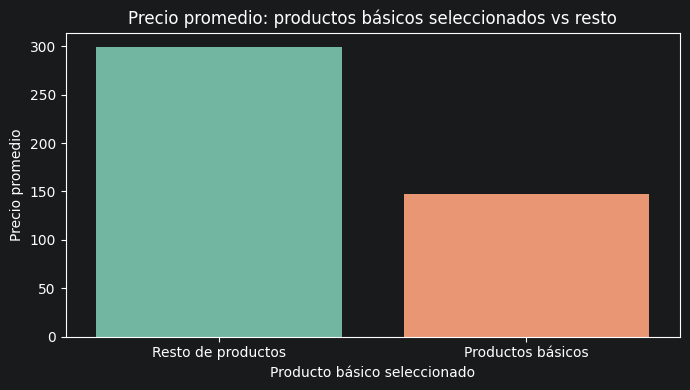

In [80]:
# PRECIO PROMEDIO: PRODUCTOS BÁSICOS VS RESTO

plt.figure(figsize=(7, 4))

sns.barplot(
    data=datos_limpios,
    x="Producto_basico",
    y="Precio",
    estimator="mean",
    errorbar=None,
    hue="Producto_basico",
    palette="Set2",
    legend=False
)

plt.title("Precio promedio: productos básicos seleccionados vs resto")
plt.xlabel("Producto básico seleccionado")
plt.ylabel("Precio promedio")
plt.xticks([0, 1], ["Resto de productos", "Productos básicos"])
plt.tight_layout()
plt.show()

### Interpretación del análisis de productos básicos

La clasificación de `Producto_basico` permite separar una selección de productos de consumo cotidiano del resto del dataset.

Esta clasificación no corresponde a una canasta básica oficial, sino a una aproximación construida a partir de palabras clave presentes en el nombre de los productos, como arroz, aceite, harina, leche, pan, fideos, huevos, carnes, agua, frutas y verduras.

Este análisis es útil porque el dataset completo incluye rubros muy distintos entre sí. Al mezclar todos los productos, los precios de rubros más caros pueden elevar el promedio general y dificultar la lectura de productos más habituales.

Por eso, la variable `Producto_basico` se incorpora como una variable auxiliar del análisis. Luego será utilizada en la aplicación interactiva como filtro adicional, permitiendo al usuario observar únicamente esta selección de productos y compararla con el resto de la base.

## Paso 8: Análisis de valores atípicos

En este paso se analizan los valores atípicos de la variable `Precio`.

Un valor atípico es un dato que se encuentra muy alejado del comportamiento general de la variable. En muchos casos puede representar un error de carga, pero en este dataset comercial también puede representar productos reales de mayor valor.

Por ese motivo, no se eliminarán automáticamente los valores extremos. Primero se analizará su comportamiento para decidir si tienen sentido dentro del contexto del negocio.

In [81]:
# PASO 8: ANÁLISIS DE VALORES ATÍPICOS

# 8.1 DETECCIÓN DE VALORES ATÍPICOS CON EL MÉTODO IQR


# Calculamos el primer cuartil, tercer cuartil y rango intercuartílico
q1 = datos_limpios["Precio"].quantile(0.25)
q3 = datos_limpios["Precio"].quantile(0.75)
iqr = q3 - q1

# Definimos los límites inferior y superior
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# Filtramos los posibles valores atípicos
outliers_precio = datos_limpios[
    (datos_limpios["Precio"] < limite_inferior) |
    (datos_limpios["Precio"] > limite_superior)
    ]

print("ANÁLISIS DE VALORES ATÍPICOS")
print("-" * 50)
print(f"Primer cuartil Q1: ${q1:.2f}")
print(f"Tercer cuartil Q3: ${q3:.2f}")
print(f"Rango intercuartílico IQR: ${iqr:.2f}")
print(f"Límite inferior: ${limite_inferior:.2f}")
print(f"Límite superior: ${limite_superior:.2f}")
print("-" * 50)
print(f"Cantidad de posibles outliers: {outliers_precio.shape[0]}")
print(f"Porcentaje de outliers: {(outliers_precio.shape[0] / datos_limpios.shape[0]) * 100:.2f}%")

ANÁLISIS DE VALORES ATÍPICOS
--------------------------------------------------
Primer cuartil Q1: $75.00
Tercer cuartil Q3: $249.00
Rango intercuartílico IQR: $174.00
Límite inferior: $-186.00
Límite superior: $510.00
--------------------------------------------------
Cantidad de posibles outliers: 2470
Porcentaje de outliers: 9.55%


### Método utilizado para detectar outliers

Para detectar posibles valores atípicos en la variable `Precio` se utiliza el método del rango intercuartílico, conocido como IQR.

Este método toma como referencia el primer cuartil y el tercer cuartil. En este dataset, la mayoría de los precios se concentra en valores relativamente bajos, pero existen productos con precios mucho más altos, llegando hasta $25.800.

El método IQR permite identificar esos precios alejados del rango principal de la distribución. Sin embargo, en este trabajo los outliers no se eliminan automáticamente. Que un precio sea marcado como valor atípico desde el punto de vista estadístico no significa que sea un error de carga.

En el contexto comercial del dataset, esos valores pueden corresponder a productos reales de rubros más caros, especialmente considerando que la base contiene grupos distintos como alimentos, limpieza, frutas y verduras, y cuidado personal.

Por ese motivo, los outliers se analizan y se visualizan, pero se conservan en el dataset final.

In [82]:
# 8.2 PRODUCTOS CON PRECIOS MÁS ALTOS

productos_mas_caros = (
    datos_limpios
    .sort_values("Precio", ascending=False)
    [["Periodo", "Super", "Grupo", "Producto", "Precio"]]
    .head(20)
)

productos_mas_caros

,Periodo,Super,Grupo,Producto,Precio
26729,Feb25,Tienda Inglesa,Cuidado Personal,Protector solar SPF 50 Eucerin 150 ml.,25800.0
26246,Abr25,San Roque,Cuidado Personal,Protector solar SPF 40 Dermaglós 250 ml.,16480.0
26718,Oct25,El Dorado,Cuidado Personal,"Crema Facial Revitalift Filler Dia, 50 ml.",14690.0
26348,Mar25,El Dorado,Cuidado Personal,"Crema Facial Revitalift Filler Dia, 50 ml.",14690.0
26833,Abr25,Farmaglobal,Cuidado Personal,"Pañales Babysec Premium Extra Extra Grande, 48...",11845.1
26510,Sep25,Farmaglobal,Cuidado Personal,"Pañales Babysec Premium Extra Extra Grande, 48...",11845.1
26444,Jun25,Farmashop,Cuidado Personal,panales para ninos comun Babysec (48 unidades),11570.0
26391,Abr25,Ta - Ta,Cuidado Personal,"Pañales Babysec Premium Extra Extra Grande, 48...",10790.0
26480,Jun25,Disco,Cuidado Personal,panales para ninos comun Babysec (48 unidades),10790.0
26629,Feb25,Ta - Ta,Cuidado Personal,"Pañales Babysec Premium Extra Extra Grande, 48...",10790.0


### Revisión de los precios más altos

Se revisan los productos con precios más altos para entender si los valores extremos pueden tener sentido dentro del contexto comercial.

En la tabla se observa que los registros más caros pertenecen principalmente al grupo `Cuidado Personal`, con productos como protectores solares, cremas faciales y pañales. Esto ayuda a explicar por qué algunos valores se alejan mucho del precio típico del dataset.

De todos modos, algunos precios son muy superiores a la mediana general de la base, por lo que deben interpretarse como valores atípicos. Esto no significa necesariamente que sean errores, pero sí que requieren una lectura cuidadosa.

Como no se cuenta con información adicional para corregir o reemplazar esos precios, no se eliminan automáticamente. Se conservan en el dataset final y se complementa el análisis con gráficos limitados al percentil 95 para observar mejor la distribución principal de precios.

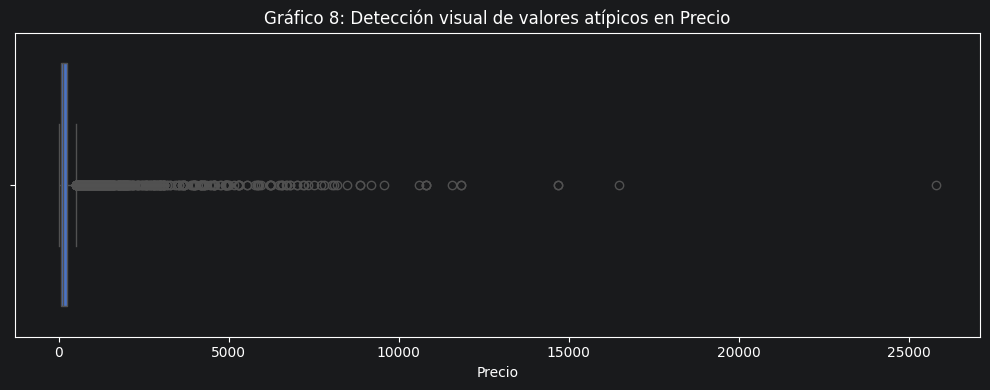

In [83]:
# 8.3 VISUALIZACIÓN GENERAL DE OUTLIERS

plt.figure(figsize=(10, 4))

sns.boxplot(
    data=datos_limpios,
    x="Precio"
)

plt.title("Gráfico 8: Detección visual de valores atípicos en Precio")
plt.xlabel("Precio")
plt.tight_layout()
plt.show()

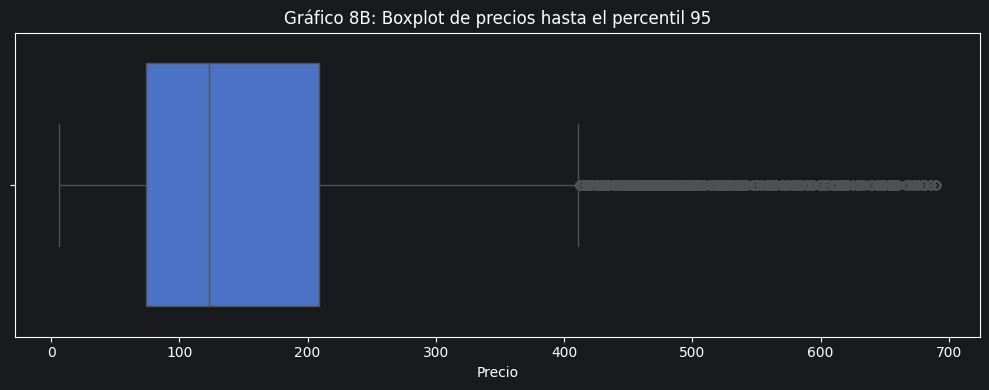

Percentil 95 de Precio: $690.00
Registros incluidos en esta visualización: 24593
Registros totales del dataset limpio: 25875


In [84]:
# VISUALIZACIÓN COMPLEMENTARIA: BOXPLOT HASTA EL PERCENTIL 95

percentil_95 = datos_limpios["Precio"].quantile(0.95)

datos_precio_p95 = datos_limpios[
    datos_limpios["Precio"] <= percentil_95
    ]

plt.figure(figsize=(10, 4))

sns.boxplot(
    data=datos_precio_p95,
    x="Precio"
)

plt.title("Gráfico 8B: Boxplot de precios hasta el percentil 95")
plt.xlabel("Precio")
plt.tight_layout()
plt.show()

print(f"Percentil 95 de Precio: ${percentil_95:.2f}")
print(f"Registros incluidos en esta visualización: {datos_precio_p95.shape[0]}")
print(f"Registros totales del dataset limpio: {datos_limpios.shape[0]}")

### Visualización complementaria de outliers

El boxplot general permite confirmar la existencia de valores extremos en la variable `Precio`, pero la presencia de precios muy altos comprime la escala del gráfico y dificulta observar la zona donde se concentra la mayoría de los registros.

Por ese motivo, se agrega una visualización complementaria hasta el percentil 95. Esta decisión no modifica el dataset ni elimina registros; únicamente mejora la lectura visual de la distribución principal de precios.

Los valores extremos se conservan porque, dentro del contexto comercial, pueden representar productos reales de mayor valor.

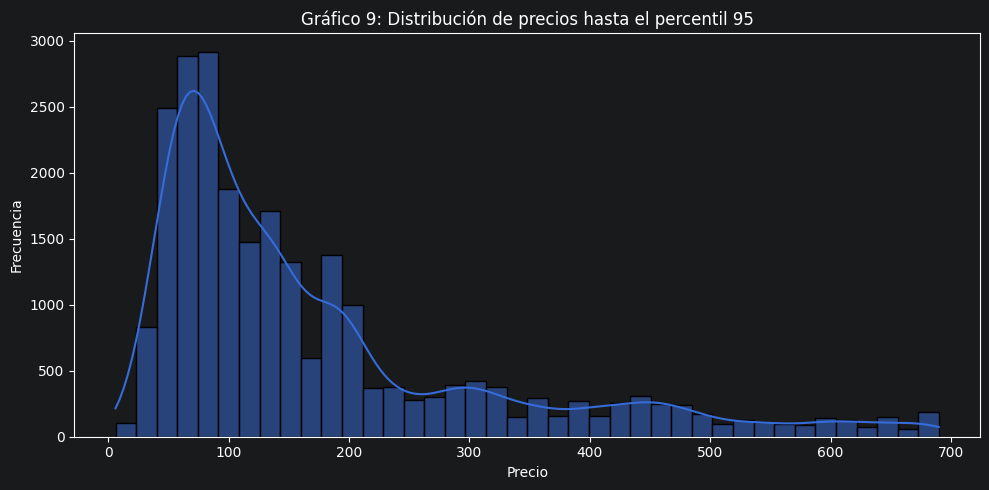

Percentil 95 de Precio: $690.00
Registros incluidos en esta visualización: 24593


In [85]:
# 8.4 DISTRIBUCIÓN DE PRECIOS SIN EXTREMOS VISUALES

# Para visualizar mejor la concentración principal de precios, grafico solo hasta el percentil 95.
percentil_95 = datos_limpios["Precio"].quantile(0.95)

datos_hasta_p95 = datos_limpios[datos_limpios["Precio"] <= percentil_95]

plt.figure(figsize=(10, 5))

sns.histplot(
    data=datos_hasta_p95,
    x="Precio",
    bins=40,
    kde=True
)

plt.title("Gráfico 9: Distribución de precios hasta el percentil 95")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(f"Percentil 95 de Precio: ${percentil_95:.2f}")
print(f"Registros incluidos en esta visualización: {datos_hasta_p95.shape[0]}")

### Visualización sin extremos superiores

Para observar mejor la distribución principal de los precios, se genera un histograma limitado hasta el percentil 95.

En este caso, el percentil 95 de la variable `Precio` es $690. Esto significa que el 95% de los registros tiene precios iguales o menores a ese valor. La visualización incluye 24.615 registros, por lo que permite analizar la mayor parte del dataset sin que los precios extremos deformen la escala del gráfico.

A diferencia del histograma completo, este gráfico muestra con mayor claridad que la mayoría de los precios se concentra en valores bajos y medios, especialmente por debajo de los $200. También se observa una cola hacia la derecha, lo que indica que siguen existiendo productos de mayor precio incluso dentro del 95% principal.

Esta limitación es solo visual: no se eliminan datos del dataset. La base completa se conserva para el análisis y para la exportación final.

In [86]:
# 8.5 DECISIÓN FINAL SOBRE VALORES ATÍPICOS

print("DECISIÓN SOBRE OUTLIERS")
print("-" * 50)
print("Los valores atípicos detectados en Precio no serán eliminados automáticamente.")
print("Motivo: en el contexto comercial, precios altos pueden corresponder a productos reales.")
print("Se conserva el dataset completo para no perder información relevante del negocio.")
print("-" * 50)
print(f"Filas conservadas en datos_limpios: {datos_limpios.shape[0]}")
print(f"Columnas conservadas en datos_limpios: {datos_limpios.shape[1]}")

DECISIÓN SOBRE OUTLIERS
--------------------------------------------------
Los valores atípicos detectados en Precio no serán eliminados automáticamente.
Motivo: en el contexto comercial, precios altos pueden corresponder a productos reales.
Se conserva el dataset completo para no perder información relevante del negocio.
--------------------------------------------------
Filas conservadas en datos_limpios: 25875
Columnas conservadas en datos_limpios: 6


### Conclusión del Paso 8

El análisis de valores atípicos muestra que la variable `Precio` presenta registros alejados del rango principal de la distribución.

Al revisar los precios más altos, se observa que varios pertenecen al grupo `Cuidado Personal`, con productos como protectores solares, cremas faciales y pañales. Por este motivo, no se puede asumir automáticamente que todos los valores extremos sean errores de carga.

Se decide no eliminar los outliers, ya que en el contexto comercial los precios altos pueden corresponder a productos reales. Esta decisión permite conservar la información completa del negocio y evitar la pérdida de registros potencialmente relevantes.

Luego de esta decisión, el dataset limpio conserva 25.897 filas y 6 columnas. La sexta columna corresponde a `Producto_basico`, creada como variable auxiliar para identificar productos básicos seleccionados.

Para mejorar la lectura visual de la distribución, se agregan gráficos complementarios limitados al percentil 95. Esta limitación es únicamente visual y no modifica el dataset final.

## Paso 9: Conclusiones generales del análisis exploratorio

A partir del análisis exploratorio realizado, se pueden extraer las siguientes conclusiones:

1. El dataset contiene información comercial sobre precios de productos relevados en distintas cadenas de supermercados de Uruguay durante 2025.

2. La variable principal del análisis es `Precio`. Las variables `Super`, `Grupo`, `Producto` y `Periodo` permiten contextualizar cada registro y analizar diferencias por cadena, rubro y momento del relevamiento.

3. Durante la limpieza fue necesario convertir la columna `Precio` a formato numérico, ya que originalmente estaba almacenada como texto con coma decimal.

4. También se normalizaron variables categóricas como `Grupo`, `Super` y `Producto`, corrigiendo diferencias de mayúsculas, minúsculas, espacios sobrantes y caracteres especiales. Esto permitió evitar categorías duplicadas por diferencias de escritura.

5. Se eliminaron los registros sin precio válido, porque `Precio` es la variable central del análisis y no corresponde reemplazarla por valores inventados.

6. Las variables categóricas con valores faltantes fueron completadas con `"Desconocido"` para conservar la mayor cantidad posible de registros útiles.

7. El análisis univariante mostró que la variable `Precio` tiene una distribución asimétrica hacia la derecha. La media es mayor que la mediana, lo que indica la presencia de productos con precios altos que elevan el promedio general.

8. El análisis por supermercado mostró diferencias en los precios promedio entre cadenas, aunque estas diferencias deben interpretarse con cuidado porque dependen también del tipo de productos relevados en cada una.

9. El análisis por grupo de producto mostró que rubros como `Cuidado Personal` presentan precios promedio más altos y concentran varios de los valores extremos observados.

10. La tabla dinámica y el mapa de calor fueron herramientas útiles para cruzar `Super`, `Grupo` y `Precio`, permitiendo observar diferencias más específicas que las que se obtienen al mirar solo promedios generales.

11. Se creó la variable auxiliar `Producto_basico` para identificar una selección aproximada de productos de consumo cotidiano. Esta clasificación no representa una canasta básica oficial, sino una selección construida mediante palabras clave presentes en el nombre de los productos.

12. Los valores atípicos detectados en `Precio` no se eliminaron, ya que pueden representar productos reales de mayor valor dentro del contexto comercial. En su lugar, se conservaron en la base y se utilizaron visualizaciones complementarias hasta el percentil 95 para mejorar la lectura gráfica.

En conclusión, el dataset queda limpio, documentado y preparado para ser utilizado en una aplicación interactiva de Streamlit. La aplicación permitirá explorar indicadores, filtros, comparaciones por supermercado, análisis por grupo de producto, productos básicos seleccionados y visualizaciones comerciales de forma dinámica.

## Paso 10: Exportación del dataset limpio

Una vez finalizado el análisis exploratorio, se exporta el dataset limpio a un archivo CSV.

Este archivo será utilizado posteriormente por `app.py`, que leerá la base procesada para construir la aplicación web interactiva en Streamlit.

De esta forma, el notebook `practice.ipynb` cumple el rol de informe y preparación de datos, mientras que `app.py` cumple el rol de script para la visualización web.

In [87]:
# PASO 10: EXPORTACIÓN DEL DATASET LIMPIO

# Ruta de salida del archivo limpio
ruta_salida = r"C:\Users\aleva\OneDrive\Escritorio\Alexia\pyhton\data\processed\p4ds_cadenas_limpio._2025.csv"

# Exportamos el dataset limpio
datos_limpios.to_csv(ruta_salida, index=False)

print("Dataset limpio exportado correctamente.")
print("-" * 50)
print("Ruta de salida:")
print(ruta_salida)
print("-" * 50)
print("Dimensiones del archivo exportado:")
print(datos_limpios.shape)

Dataset limpio exportado correctamente.
--------------------------------------------------
Ruta de salida:
C:\Users\aleva\OneDrive\Escritorio\Alexia\pyhton\data\processed\p4ds_cadenas_limpio._2025.csv
--------------------------------------------------
Dimensiones del archivo exportado:
(25875, 6)


### Cierre del notebook

El archivo limpio fue exportado correctamente en formato CSV.

Este archivo constituye la salida final del proceso de limpieza y análisis exploratorio realizado en el notebook. A partir de él se puede alimentar la aplicación desarrollada en Streamlit, manteniendo separados los objetivos de ambos archivos:

- `practice.ipynb`: informe, exploración, limpieza y conclusiones.
- `app.py`: lectura del CSV limpio y construcción de visualizaciones interactivas.